# Supplementary Figure S5(E) — Pair-score trend within fixed resolution bands

Pair score vs year within fixed resolution bands (cryo-EM).

In [1]:
import json
from datetime import datetime
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_ROOT = Path.cwd().parent.parent
FIGURES = _ROOT / "figures"

def data_file(rel):
    return _ROOT / "data" / rel

def savefig(fig, name, dpi=150):
    FIGURES.mkdir(exist_ok=True)
    fig.savefig(FIGURES / name, dpi=dpi, bbox_inches="tight")
    return Path("figures") / name

In [2]:
def _resolution(m):
    return (m.get("EM Diffraction Resolution (Å)") or m.get("Refinement_resolution")
            or m.get("EM Resolution (Å)"))


def _year(s):
    if not s:
        return None
    try:
        return datetime.fromisoformat(s).year
    except Exception:
        return None


def load_temporal_df():
    """Per-structure rows (>=5 pairs) with year, method, resolution, pairs_score."""
    sc = json.load(open(data_file("reference/scores/scores_all_uniques.json")))["scores"]
    vm = json.load(open(data_file("reference/metadata/metadata_cache.json")))["validation_metrics"]
    rows = []
    for pdb, info in sc.items():
        m = vm.get(pdb)
        if not isinstance(m, dict):
            continue
        year = _year(m.get("Deposition_Date"))
        method = m.get("Experimental_method")
        res = _resolution(m)
        if year is None or method not in ("X-ray", "EM") or res is None or res <= 0:
            continue
        rows.append({"pdb": pdb, "year": year, "method": method, "resolution": res,
                     "pairs_score": info["pairs_score"], "n_pairs": info.get("n_pairs", 0)})
    df = pd.DataFrame(rows)
    return df[df["n_pairs"] >= 5].reset_index(drop=True)


def yearly_agg(df):
    agg = (df.groupby(["method", "year"])
             .agg(resolution_mean=("resolution", "mean"), resolution_sem=("resolution", "sem"),
                  pairs_mean=("pairs_score", "mean"), pairs_sem=("pairs_score", "sem"),
                  n=("pdb", "count"))
             .reset_index().sort_values(["method", "year"]))
    for c in ("resolution_sem", "pairs_sem"):
        agg[c] = agg[c].fillna(0)
    return agg

In [3]:
df = load_temporal_df()
agg = yearly_agg(df)
em = df[df['method'] == 'EM'].dropna(subset=['year', 'resolution', 'pairs_score']).copy()

saved figures/figS5_E_trend_within_resolution_bands.png


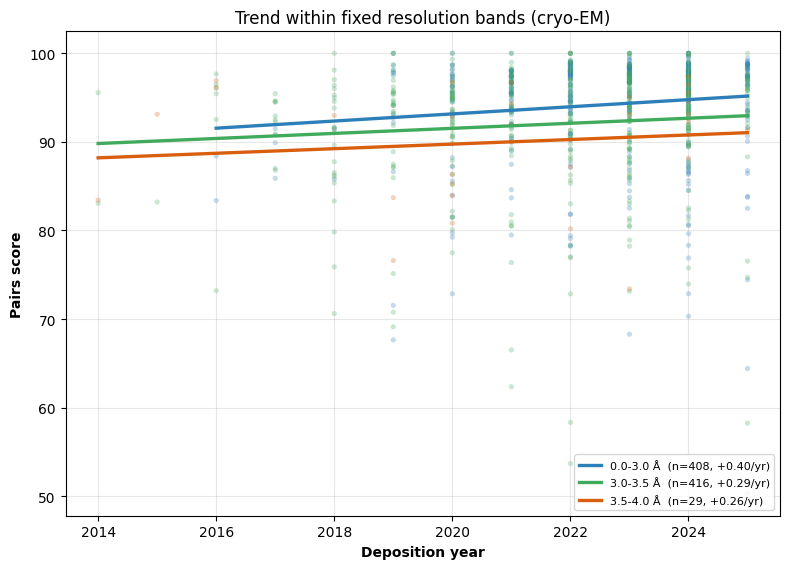

In [4]:
yr = em['year'].to_numpy(float); res = em['resolution'].to_numpy(float); ps = em['pairs_score'].to_numpy(float)
fig, ax = plt.subplots(figsize=(8, 5.8))
for (lo, hi), c in zip([(0, 3.0), (3.0, 3.5), (3.5, 4.0)], ['#2c7fb8', '#41ab5d', '#d95f0e']):
    m = (res >= lo) & (res < hi)
    if m.sum() < 15: continue
    s3, b3 = np.polyfit(yr[m], ps[m], 1)
    ax.scatter(yr[m], ps[m], s=14, alpha=0.28, color=c, edgecolor='none')
    xx = np.linspace(yr[m].min(), yr[m].max(), 50)
    ax.plot(xx, s3*xx + b3, color=c, lw=2.4, zorder=5, label=f'{lo:.1f}-{hi:.1f} \u00c5  (n={m.sum()}, {s3:+.2f}/yr)')
ax.set_xlabel('Deposition year', fontweight='bold'); ax.set_ylabel('Pairs score', fontweight='bold')
ax.set_title('Trend within fixed resolution bands (cryo-EM)'); ax.grid(alpha=0.3)
ax.legend(loc='lower right', fontsize=8)
fig.tight_layout(); print('saved', savefig(fig, 'figS5_E_trend_within_resolution_bands.png')); plt.show()